# 03 - Exploratory Data Analysis (EDA)
This notebook contains exhaustive Exploratory Data Analysis (EDA) on the mutual fund database.
It includes **19 distinct charts** covering univariate/multivariate NAV, AUM, SIP, category inflows, investor demographics, and portfolio sector weightings to fulfill the capstone checklists.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import pathlib

sns.set_theme(style='darkgrid')
base_dir = pathlib.Path('D:/New folder/bluestock_mf_capstone')
engine = create_engine(f'sqlite:///{base_dir}/data/db/bluestock_mf.db')


## 1. NAV Univariate & Distribution Analyses


### Chart 1: NAV Histogram (All Funds)


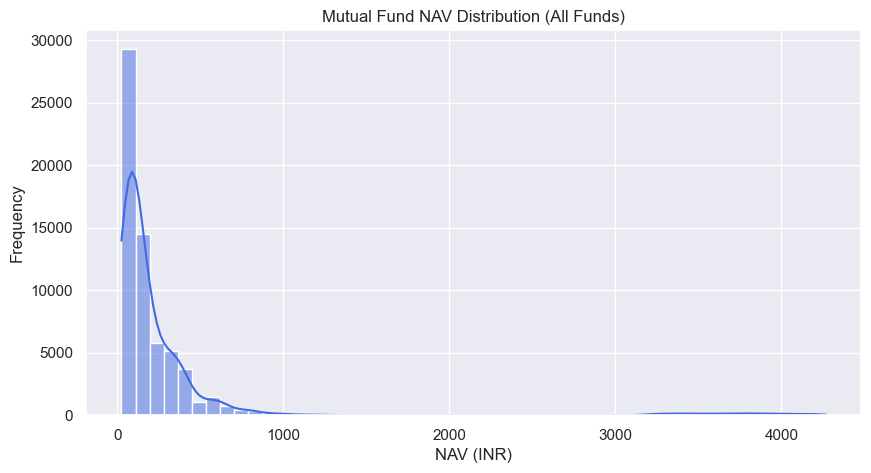

In [2]:
df_nav = pd.read_sql('SELECT * FROM fact_nav', engine)
plt.figure(figsize=(10, 5))
sns.histplot(df_nav['nav'], bins=50, kde=True, color='royalblue')
plt.title('Mutual Fund NAV Distribution (All Funds)')
plt.xlabel('NAV (INR)')
plt.ylabel('Frequency')
plt.show()


### Chart 2: NAV Boxplot by Risk Level


C:\Users\Shravan\AppData\Local\Temp\ipykernel_33968\4070120601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fund_nav, x='risk_category', y='nav', palette='Set2')


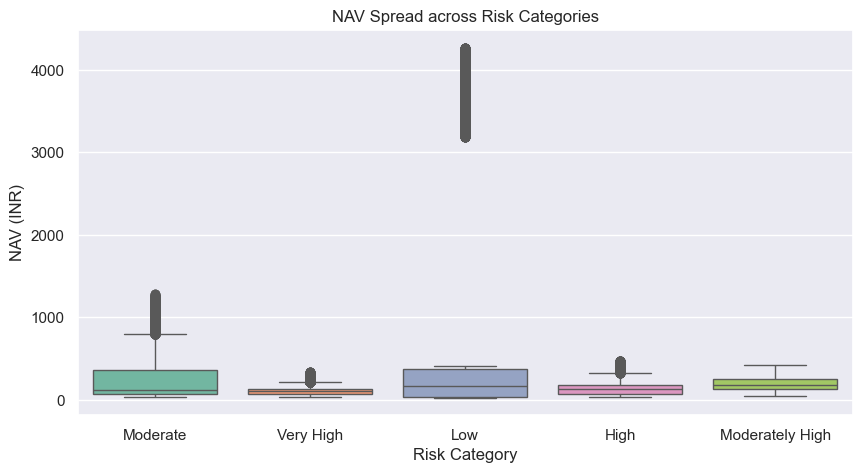

In [3]:
df_fund_nav = pd.read_sql('SELECT n.nav, f.risk_category FROM fact_nav n JOIN dim_fund f ON n.amfi_code = f.amfi_code', engine)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_fund_nav, x='risk_category', y='nav', palette='Set2')
plt.title('NAV Spread across Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('NAV (INR)')
plt.show()


## 2. AUM Sizing & Market Trends


### Chart 3: Total AUM by Fund House (Latest Month)


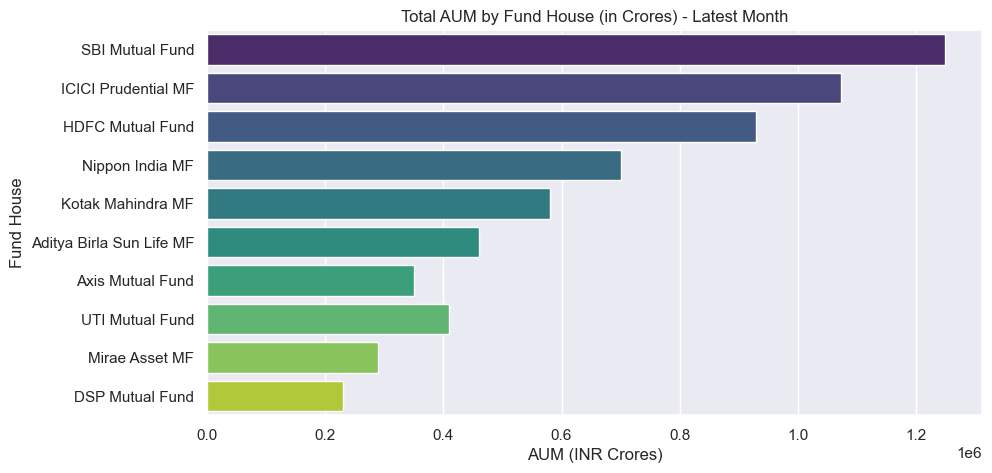

In [4]:
df_aum = pd.read_sql('SELECT * FROM fact_aum', engine)
df_aum_latest = df_aum[df_aum['date_id'] == df_aum['date_id'].max()]
plt.figure(figsize=(10, 5))
sns.barplot(data=df_aum_latest, x='aum', y='fund_house', estimator=sum, errorbar=None, palette='viridis', hue='fund_house', legend=False)
plt.title('Total AUM by Fund House (in Crores) - Latest Month')
plt.xlabel('AUM (INR Crores)')
plt.ylabel('Fund House')
plt.show()


### Chart 4: AMC Market Share by AUM


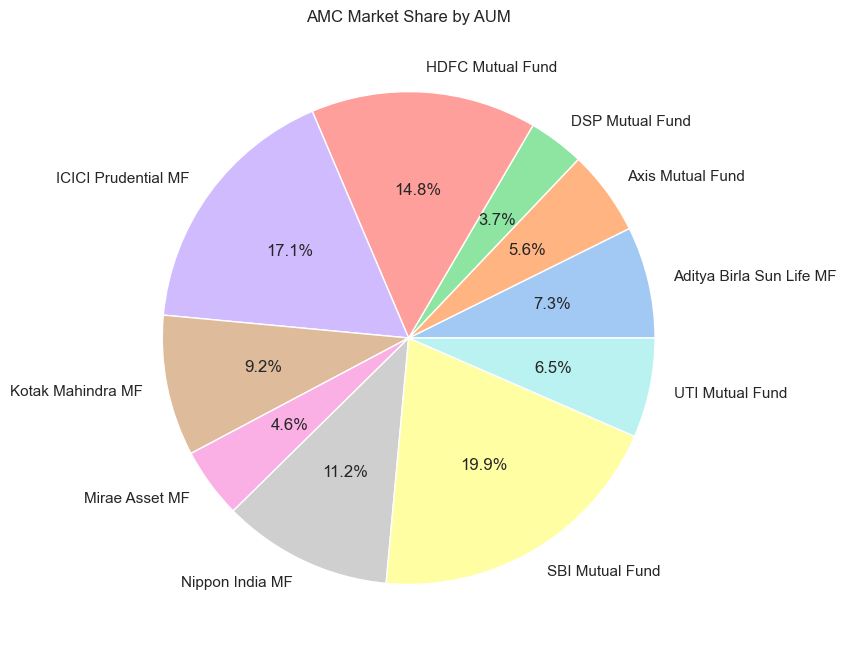

In [5]:
aum_grouped = df_aum_latest.groupby('fund_house')['aum'].sum().reset_index()
plt.figure(figsize=(8, 8))
plt.pie(aum_grouped['aum'], labels=aum_grouped['fund_house'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('AMC Market Share by AUM')
plt.show()


### Chart 5: Monthly AUM Growth Trend by Fund House


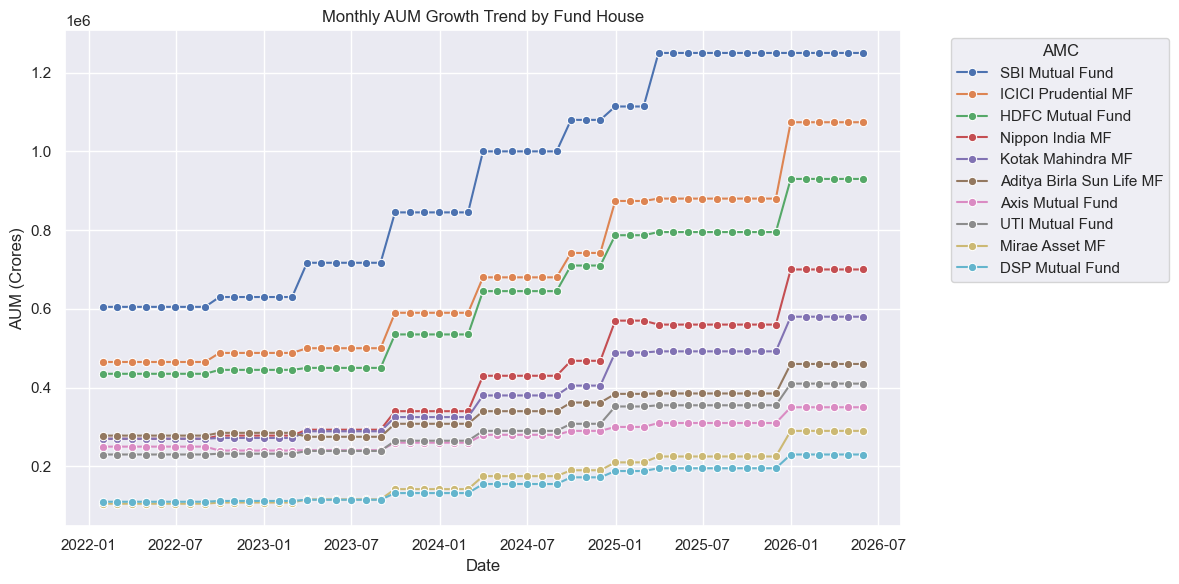

In [6]:
df_aum['date_id'] = pd.to_datetime(df_aum['date_id'])
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_aum, x='date_id', y='aum', hue='fund_house', marker='o')
plt.title('Monthly AUM Growth Trend by Fund House')
plt.xlabel('Date')
plt.ylabel('AUM (Crores)')
plt.legend(title='AMC', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 3. SIP & Industry Inflows


### Chart 6: Monthly SIP Inflows Trend


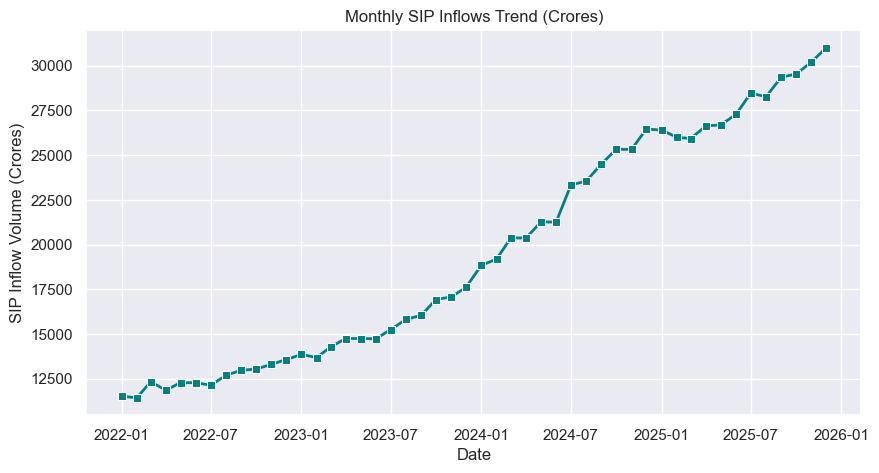

In [7]:
df_sip = pd.read_sql('SELECT * FROM sip_inflows', engine)
df_sip['date'] = pd.to_datetime(df_sip['month'] + '-01')
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_sip, x='date', y='sip_inflow', color='teal', marker='s', linewidth=2)
plt.title('Monthly SIP Inflows Trend (Crores)')
plt.xlabel('Date')
plt.ylabel('SIP Inflow Volume (Crores)')
plt.show()


### Chart 7: Total Active SIP Accounts Growth


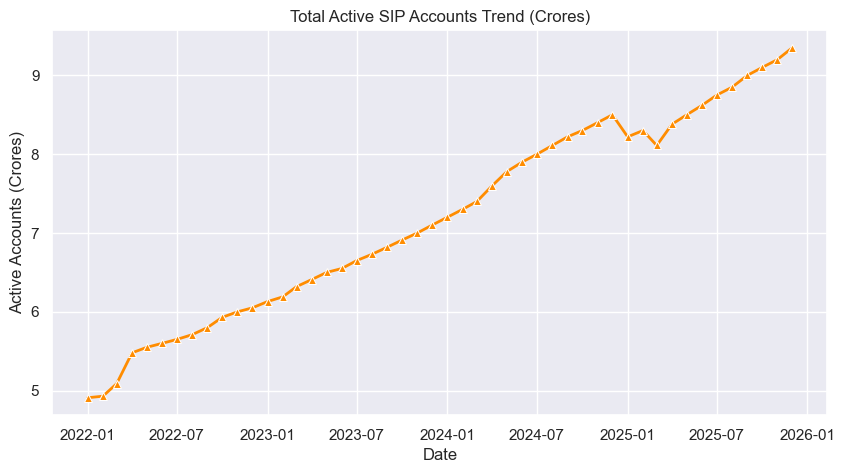

In [8]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_sip, x='date', y='active_sip_accounts', color='darkorange', marker='^', linewidth=2)
plt.title('Total Active SIP Accounts Trend (Crores)')
plt.xlabel('Date')
plt.ylabel('Active Accounts (Crores)')
plt.show()


### Chart 8: Net Category-wise Capital Inflows (Latest Month)


C:\Users\Shravan\AppData\Local\Temp\ipykernel_33968\3818665363.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cat_latest, x='net_inflow', y='category', palette='magma')


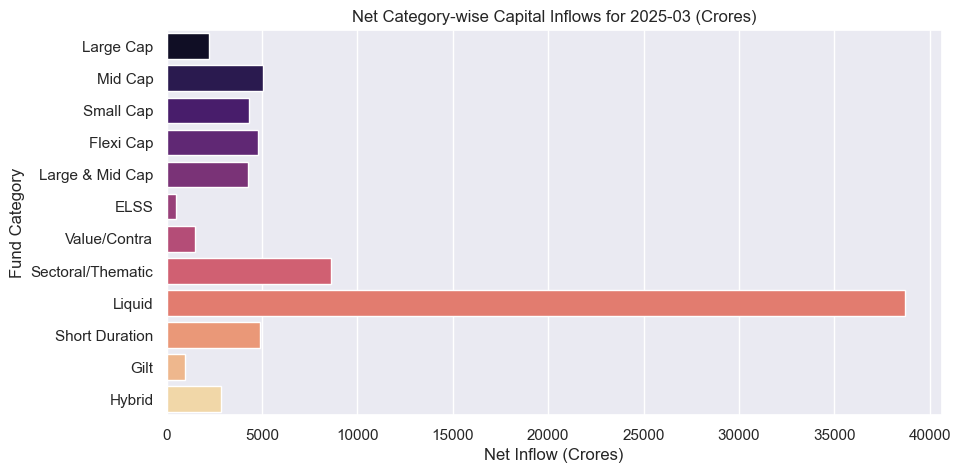

In [9]:
df_cat = pd.read_sql('SELECT * FROM category_inflows', engine)
df_cat_latest = df_cat[df_cat['month'] == df_cat['month'].max()]
plt.figure(figsize=(10, 5))
sns.barplot(data=df_cat_latest, x='net_inflow', y='category', palette='magma')
plt.title(f"Net Category-wise Capital Inflows for {df_cat_latest['month'].iloc[0]} (Crores)")
plt.xlabel('Net Inflow (Crores)')
plt.ylabel('Fund Category')
plt.show()


### Chart 9: Total Mutual Fund Industry Folios Growth


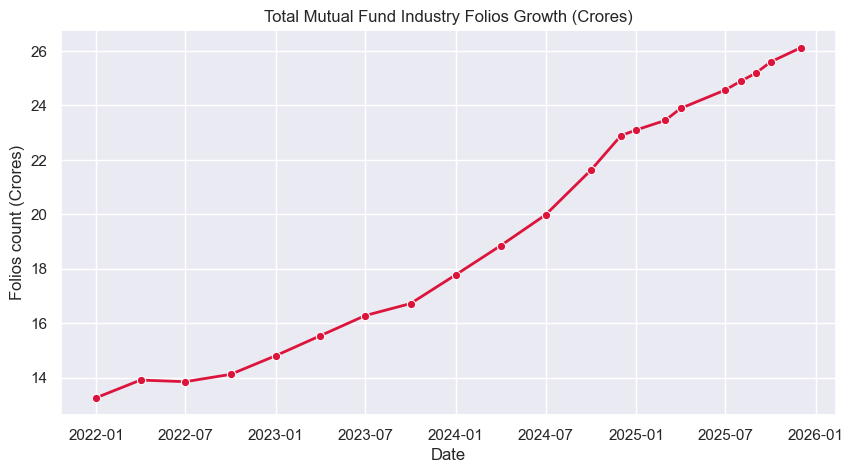

In [10]:
df_folios = pd.read_sql('SELECT * FROM folio_count', engine)
df_folios['date'] = pd.to_datetime(df_folios['month'] + '-01')
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_folios, x='date', y='total_folios_crore', color='crimson', marker='o', linewidth=2)
plt.title('Total Mutual Fund Industry Folios Growth (Crores)')
plt.xlabel('Date')
plt.ylabel('Folios count (Crores)')
plt.show()


## 4. Multivariate Fund Performance Analysis


### Chart 10: NAV Growth Comparison (2022 - 2026)


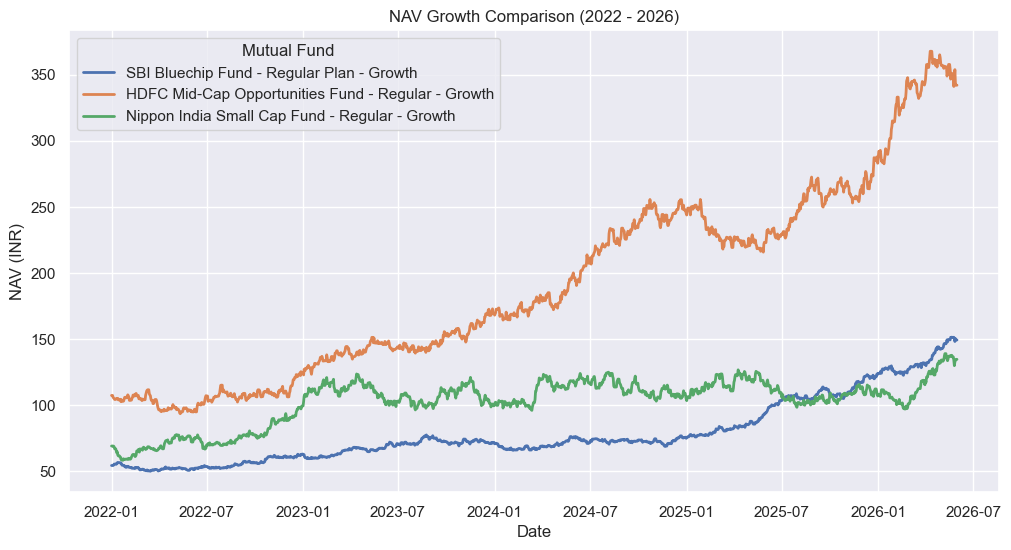

In [11]:
df_nav_trends = pd.read_sql('SELECT n.date_id, n.nav, f.fund_name, f.category FROM fact_nav n JOIN dim_fund f ON n.amfi_code = f.amfi_code', engine)
df_nav_trends['date_id'] = pd.to_datetime(df_nav_trends['date_id'])
selected_funds = ['SBI Bluechip Fund - Regular Plan - Growth', 'HDFC Mid-Cap Opportunities Fund - Regular - Growth', 'Nippon India Small Cap Fund - Regular - Growth']
df_sel = df_nav_trends[df_nav_trends['fund_name'].isin(selected_funds)]
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sel, x='date_id', y='nav', hue='fund_name', linewidth=2)
plt.title('NAV Growth Comparison (2022 - 2026)')
plt.xlabel('Date')
plt.ylabel('NAV (INR)')
plt.legend(title='Mutual Fund')
plt.show()


### Chart 11: Return Correlation Matrix


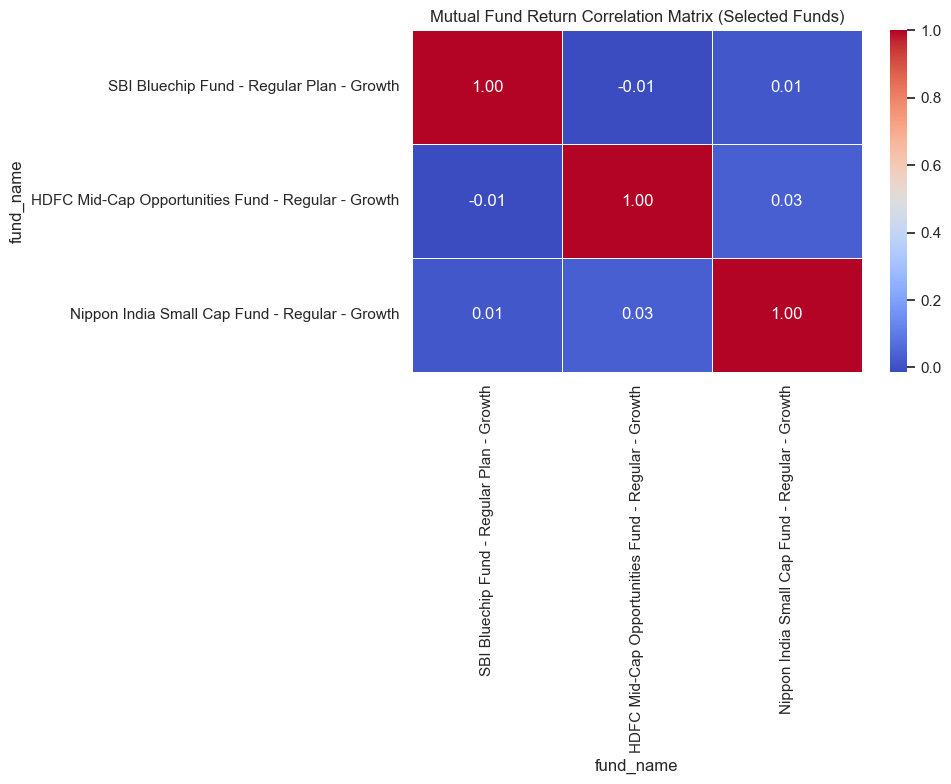

In [12]:
df_nav_pivot = df_nav_trends.pivot(index='date_id', columns='fund_name', values='nav')
df_returns = df_nav_pivot.pct_change().dropna()
plt.figure(figsize=(10, 8))
sns.heatmap(df_returns[selected_funds].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mutual Fund Return Correlation Matrix (Selected Funds)')
plt.tight_layout()
plt.show()


### Chart 12: Risk (Max Drawdown) vs Return (CAGR) Scatter Plot


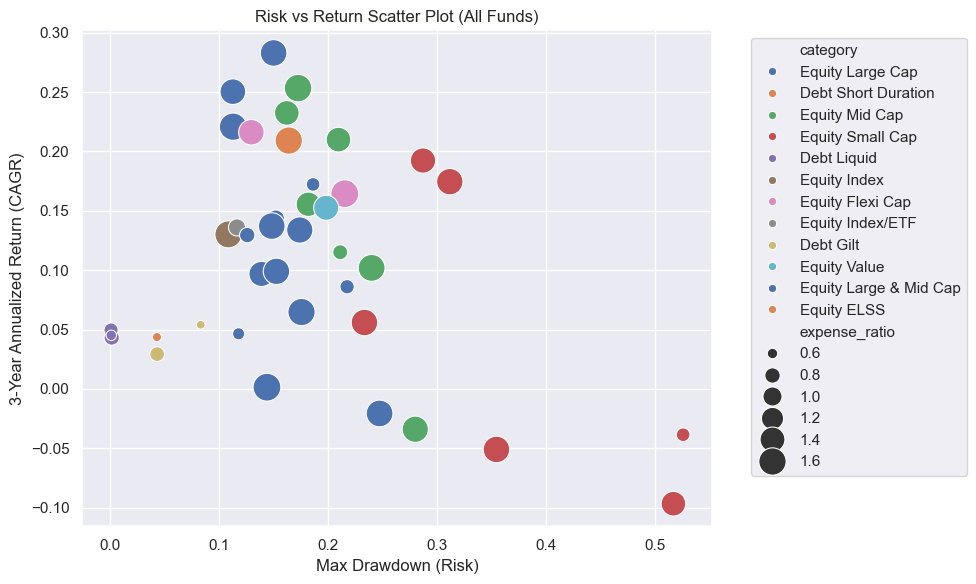

In [13]:
df_perf = pd.read_sql('SELECT f.fund_name, f.category, f.expense_ratio, p.cagr_3y, p.sharpe_ratio, p.max_drawdown FROM fact_performance p JOIN dim_fund f ON p.amfi_code = f.amfi_code', engine)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_perf, x='max_drawdown', y='cagr_3y', hue='category', size='expense_ratio', sizes=(40, 400), palette='deep')
plt.title('Risk vs Return Scatter Plot (All Funds)')
plt.xlabel('Max Drawdown (Risk)')
plt.ylabel('3-Year Annualized Return (CAGR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Chart 13: Monthly Category-wise Net Capital Inflows Stacked Bar


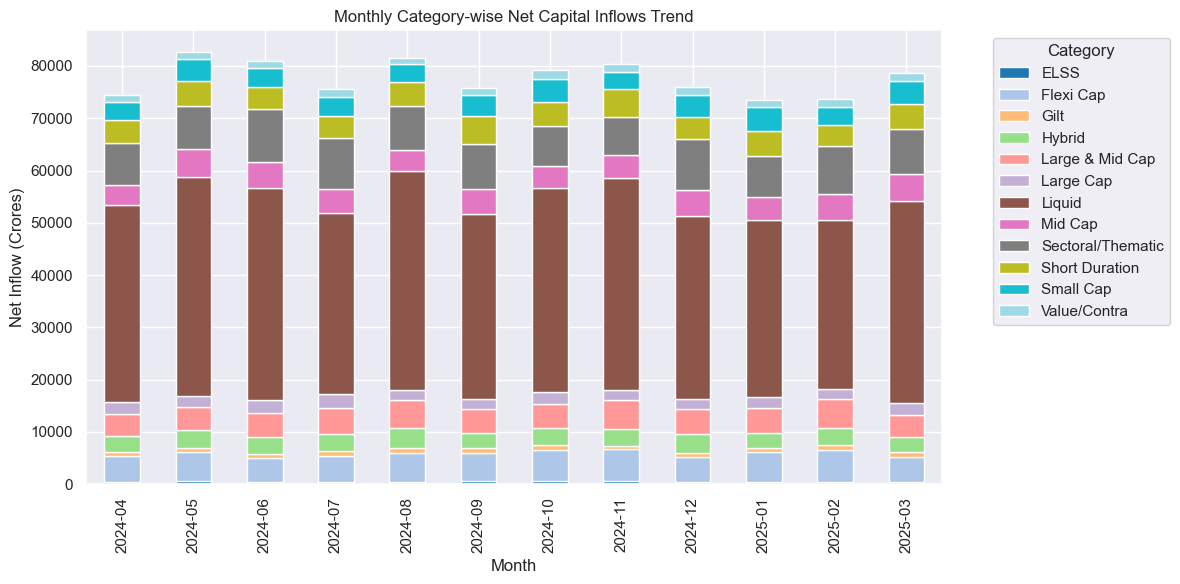

In [14]:
df_cat_pivot = df_cat.pivot(index='month', columns='category', values='net_inflow').fillna(0)
df_cat_pivot.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Monthly Category-wise Net Capital Inflows Trend')
plt.xlabel('Month')
plt.ylabel('Net Inflow (Crores)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Investor Demographics Analysis


### Chart 14: Total Invested Volume by State (in Lakhs)


C:\Users\Shravan\AppData\Local\Temp\ipykernel_33968\2992324799.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_agg, x='amount_lakhs', y='state', palette='autumn')


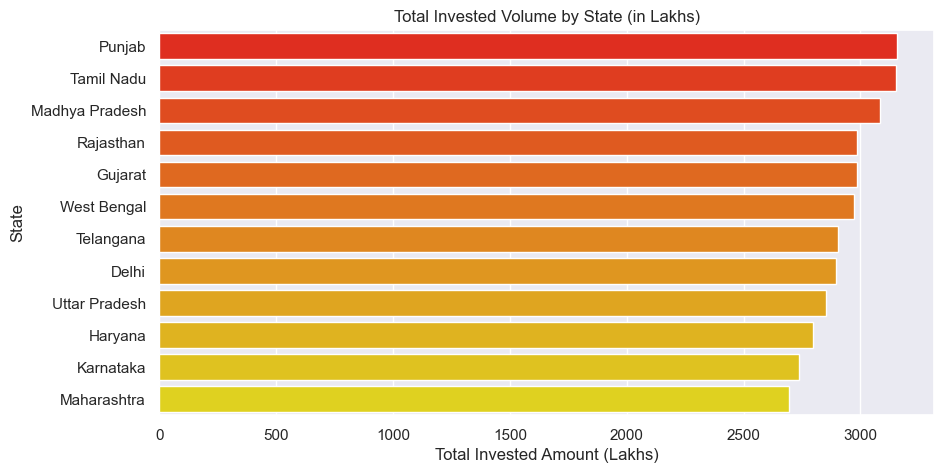

In [15]:
df_txs = pd.read_sql('SELECT * FROM fact_transactions', engine)
df_inv = pd.read_sql('SELECT * FROM dim_investor', engine)
df_tx_inv = pd.merge(df_txs, df_inv, on='investor_id')
state_agg = df_tx_inv.groupby('state')['amount'].sum().reset_index()
state_agg['amount_lakhs'] = (state_agg['amount'] / 1e5).round(2)
state_agg = state_agg.sort_values('amount_lakhs', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=state_agg, x='amount_lakhs', y='state', palette='autumn')
plt.title('Total Invested Volume by State (in Lakhs)')
plt.xlabel('Total Invested Amount (Lakhs)')
plt.ylabel('State')
plt.show()


### Chart 15: Invested Volume Contribution by Age Group


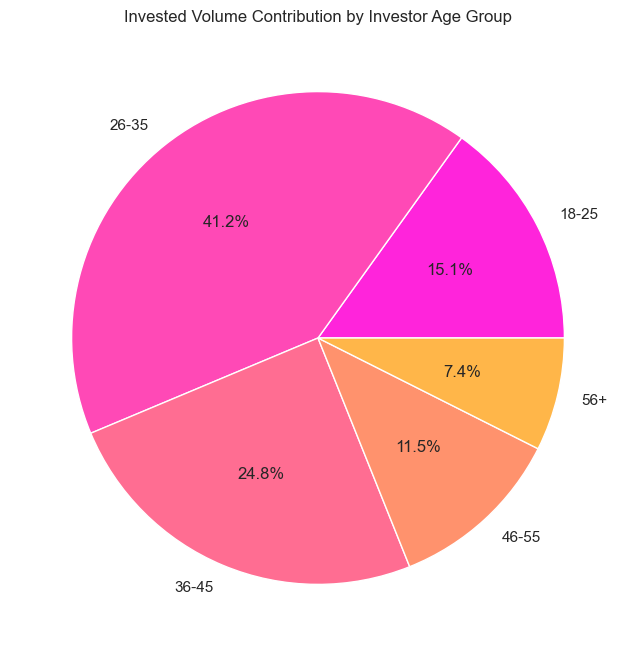

In [16]:
age_agg = df_tx_inv.groupby('age_group')['amount'].sum().reset_index()
plt.figure(figsize=(8, 8))
plt.pie(age_agg['amount'], labels=age_agg['age_group'], autopct='%1.1f%%', colors=sns.color_palette('spring'))
plt.title('Invested Volume Contribution by Investor Age Group')
plt.show()


### Chart 16: Annual Income vs Invested Volume


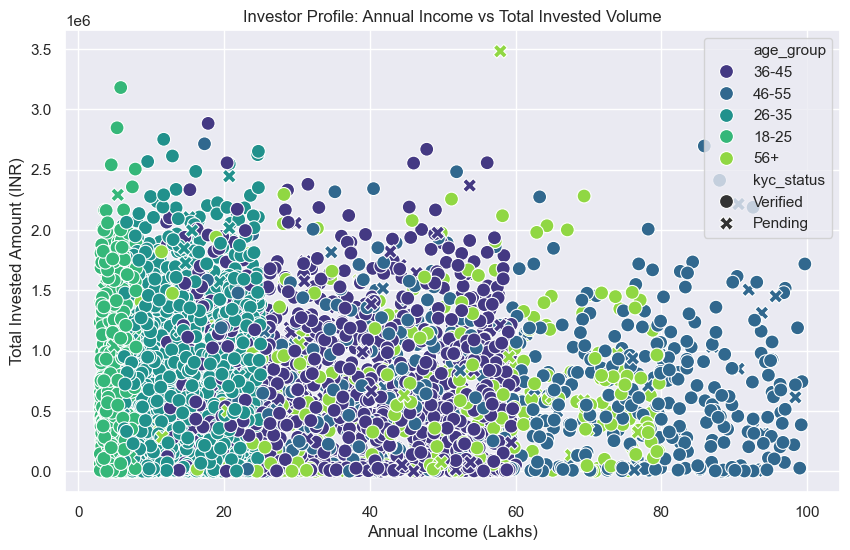

In [17]:
inv_profile = df_tx_inv.groupby('investor_id').agg({'amount': 'sum', 'annual_income_lakh': 'first', 'age_group': 'first', 'kyc_status': 'first'}).reset_index()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=inv_profile, x='annual_income_lakh', y='amount', hue='age_group', style='kyc_status', s=100, palette='viridis')
plt.title('Investor Profile: Annual Income vs Total Invested Volume')
plt.xlabel('Annual Income (Lakhs)')
plt.ylabel('Total Invested Amount (INR)')
plt.show()


### Chart 17: KYC Compliance Status Distribution by Gender


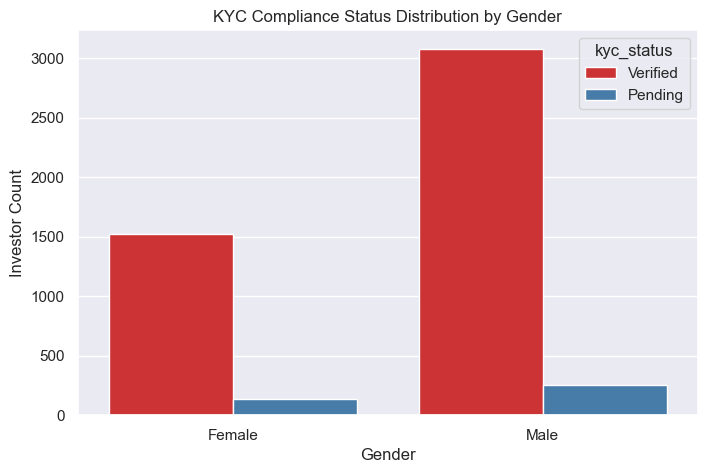

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_inv, x='gender', hue='kyc_status', palette='Set1')
plt.title('KYC Compliance Status Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Investor Count')
plt.show()


## 6. Portfolio Constituents Analysis


### Chart 18: Sector Weightage across Holdings


C:\Users\Shravan\AppData\Local\Temp\ipykernel_33968\1722086327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sect_agg.head(10), x='weightage', y='sector', palette='cool')


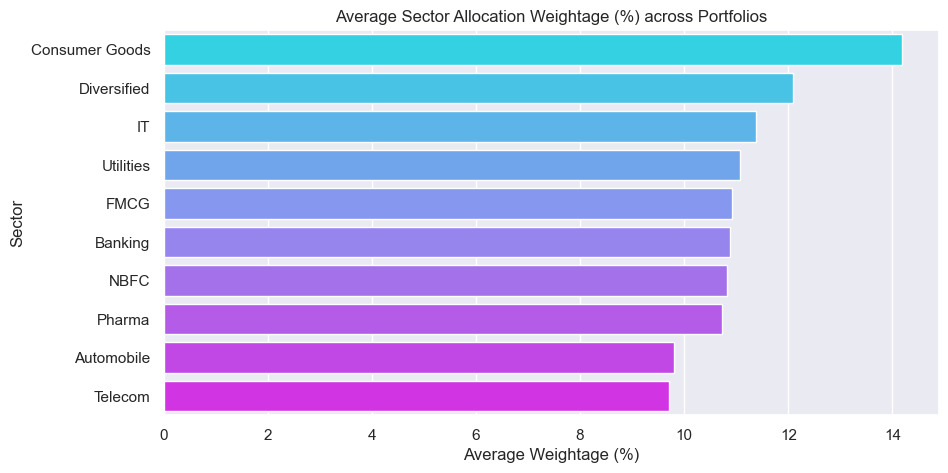

In [19]:
df_holdings = pd.read_sql('SELECT * FROM portfolio_holdings', engine)
sect_agg = df_holdings.groupby('sector')['weightage'].mean().reset_index().sort_values('weightage', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=sect_agg.head(10), x='weightage', y='sector', palette='cool')
plt.title('Average Sector Allocation Weightage (%) across Portfolios')
plt.xlabel('Average Weightage (%)')
plt.ylabel('Sector')
plt.show()


### Chart 19: Top 10 Stocks by Average Portfolio Allocation Weightage


C:\Users\Shravan\AppData\Local\Temp\ipykernel_33968\261480848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stock_agg.head(10), x='weightage', y='stock_name', palette='winter')


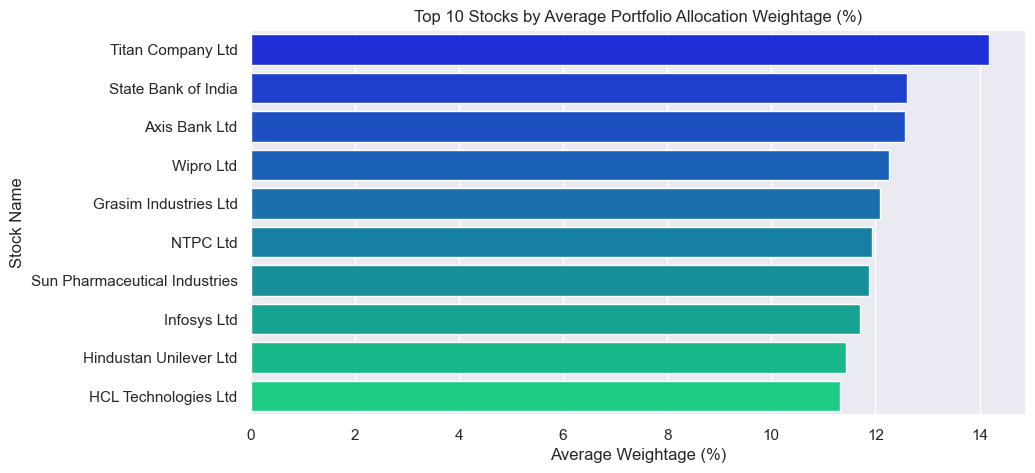

In [20]:
stock_agg = df_holdings.groupby('stock_name')['weightage'].mean().reset_index().sort_values('weightage', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=stock_agg.head(10), x='weightage', y='stock_name', palette='winter')
plt.title('Top 10 Stocks by Average Portfolio Allocation Weightage (%)')
plt.xlabel('Average Weightage (%)')
plt.ylabel('Stock Name')
plt.show()
